In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os
import gsw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml, os
import nc_time_axis, cftime
from datetime import datetime
import getpass
import xarray as xr
from mom6_tools.stats import extract_time_series, ocean_stats
from mom6_tools.m6toolbox import cime_xmlquery, genBasinMasks, weighted_temporal_mean_vars, add_global_attrs
from mom6_tools.MOM6grid import MOM6grid
from mom6_tools.poleward_heat_transport import  *

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


Basemap module not found. Some regional plots may not function properly


In [2]:
# Make the graphs a bit prettier, and bigger
#plt.style.use('seaborn-v0_8-whitegrid')
#pd.set_option('display.width', 5000)
#pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

In [3]:
class Experiment():
    def __init__(self, diag_config_yml_path = "no-GM.yaml"):
        # Read config file
        diag_config_yml = yaml.load(open(diag_config_yml_path,'r'), Loader=yaml.Loader)

        # Read paths
        caseroot = diag_config_yml['Case']['CASEROOT']
        casename = cime_xmlquery(caseroot, 'CASE')
        DOUT_S = cime_xmlquery(caseroot, 'DOUT_S')
        rundir = cime_xmlquery(caseroot, 'RUNDIR')
        
        if DOUT_S:
          OUTDIR = cime_xmlquery(caseroot, 'DOUT_S_ROOT')+'/ocn/hist/'
        else:
          OUTDIR = cime_xmlquery(caseroot, 'RUNDIR')
        
        print('Rundir directory is:', rundir)
        print('Casename is:', casename)
    
        # Organize paths as a classcreate an empty class object
        class args:
          pass
        
        args.rundir = rundir
        args.casename = casename
        args.caseroot = caseroot
        args.OUTDIR = OUTDIR
        args.ICEDIR = cime_xmlquery(caseroot, 'DOUT_S_ROOT') + '/ice/hist'
        args.nw = 1
        args.savefigs = False
        args.static = casename+diag_config_yml['Fnames']['static']
        args.native = casename+diag_config_yml['Fnames']['native']
        args.ice = casename+diag_config_yml['Fnames']['ice']
        args.geom =   casename+diag_config_yml['Fnames']['geom']
        avg = diag_config_yml['Avg']
        args.start_date = avg['start_date']
        args.end_date = avg['end_date']
        
        # Save paths as a class field
        self.args = args

        # read grid info
        geom_file = OUTDIR+'/'+args.geom
        if os.path.exists(geom_file):
          grd = MOM6grid(OUTDIR+'/'+args.static, geom_file, xrformat=True)
        else:
          grd = MOM6grid(OUTDIR+'/'+args.static, xrformat=True)
        
        try:
          depth = grd.depth_ocean.values
        except:
          depth = grd.deptho.values
        
        try:
          area = grd.area_t.where(grd.wet > 0)
        except:
          area = grd.areacello.where(grd.wet > 0)

        # basin masks - remove Nan's, otherwise genBasinMasks won't work
        depth[np.isnan(depth)] = 0.0
        basin_code = genBasinMasks(grd.geolon.values, grd.geolat.values, depth, verbose=False)
        basin_code_xr = genBasinMasks(grd.geolon.values, grd.geolat.values, depth, verbose=False, xda=True)

        self.grd = grd
        self.depth = depth
        self.area = area
        self.basin_code = basin_code
        self.basin_code_xr = basin_code_xr

    def compute_and_average_heat_fluxes(self):
        print('Reading dataset...')
        ds = xr.open_mfdataset(self.args.OUTDIR+'/'+self.args.native, \
         parallel=True, data_vars='minimal', chunks={'time': 12},\
         coords='minimal', compat='override')[['T_ady_2d', 'T_diffy_2d', 'T_hbd_diffy_2d']]
        print('Dataset is initialized.')

        print('\n Selecting and loading data between {} and {}...'.format(self.args.start_date, self.args.end_date))
        ds_sel = ds.sel(time=slice(self.args.start_date, self.args.end_date)).load()

        attrs =  {
         'description': 'Annual mean of poleward heat transport by components ',
         'start_date': self.args.start_date,
         'end_date': self.args.end_date,
         'reduction_method': 'annual mean weighted by days in each month',
         'casename': self.args.casename
         }

        print('Computing annual mean...')
        ds_ann =  weighted_temporal_mean_vars(ds_sel,attrs=attrs)

        print('Computing time-average over all selected data...')
        ds_mean = ds_ann.mean('time').load()

        print('Saving heat fluxes to file...')
        attrs = {'description': 'Time-mean poleward heat transport by components ', 'units': ds['T_ady_2d'].units,
                 'start_date': self.args.start_date, 'end_date': self.args.end_date, 'casename': self.args.casename}
        add_global_attrs(ds_mean,attrs)
        ds_mean.to_netcdf('ncfiles_coupled/'+self.args.casename+'_heat_transport.nc')

    def compute_ice(self):
      print('Reading dataset...')
      ds = xr.open_mfdataset(self.args.ICEDIR+'/'+self.args.ice, \
        parallel=True, data_vars='minimal', \
        coords='minimal', compat='override', preprocess=lambda ds: ds[['hi']])
      
      ice_volume = ds.hi.rename({'nj': 'yh', 'ni': 'xh'}) * self.area
      yh = ice_volume.yh

      dataset = xr.Dataset()
      dataset['ice_volume_NH']= (ice_volume).where(yh>0).sum(['xh', 'yh'])
      dataset['ice_volume_SH'] = (ice_volume).where(yh<0).sum(['xh', 'yh'])
        
      with ProgressBar():
         dataset.to_netcdf('ncfiles_coupled/'+self.args.casename+'_ice_volume.nc')

    def heat_transport(self):
      ds = xr.open_dataset('ncfiles_coupled/'+self.args.casename+'_heat_transport.nc').fillna(0.)
      return ds['T_ady_2d'], ds['T_diffy_2d'], ds['T_hbd_diffy_2d']
  
    def thetao(self):
      ds = xr.open_dataset('ncfiles_coupled/'+self.args.casename+'_thetao_time_mean.nc')
      return ds
  
    def so(self):
      ds = xr.open_dataset('ncfiles_coupled/'+self.args.casename+'_so_time_mean.nc')
      return ds
  
    def ice_volume(self):
       return xr.open_dataset('ncfiles_coupled/'+self.args.casename+'_ice_volume.nc')

    def sigma2(self):
      thetao = self.thetao().thetao
      so = self.so().so
      return gsw.sigma2(so, thetao)

    def mld_winter(self):
      ds = xr.open_dataset('ncfiles_coupled/'+self.args.casename+'_MLD_winter.nc')
      return ds

    def mld_summer(self):
      ds = xr.open_dataset('ncfiles_coupled/'+self.args.casename+'_MLD_summer.nc')
      return ds

In [ ]:
exps = {}
for exp in ['CTRL_8years', 'coupled_bANN_0.3_8years', 'coupled_bANN_1.0_8years', 'coupled_bANN_0.3_eANN_8years', 'coupled_bANN_0.3_ANN_8years', 'coupled_ANN_8years', 'coupled_eANN_8years']:
    exps[exp.removesuffix('_8years')] = Experiment(f'{exp}.yaml')

Rundir directory is: /glade/derecho/scratch/jiarongw/CTRL/run
Casename is: CTRL
MOM6 grid successfully loaded... 

Rundir directory is: /glade/derecho/scratch/pavelp/coupled_bANN_0.3/run
Casename is: coupled_bANN_0.3
MOM6 grid successfully loaded... 

Rundir directory is: /glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
Casename is: coupled_bANN_1.0
MOM6 grid successfully loaded... 

Rundir directory is: /glade/derecho/scratch/pavelp/coupled_bANN_0.3_eANN/run
Casename is: coupled_bANN_0.3_eANN
MOM6 grid successfully loaded... 

Rundir directory is: /glade/derecho/scratch/pavelp/coupled_bANN_0.3_ANN/run
Casename is: coupled_bANN_0.3_ANN
MOM6 grid successfully loaded... 

Rundir directory is: /glade/derecho/scratch/pavelp/coupled_ANN/run
Casename is: coupled_ANN
MOM6 grid successfully loaded... 

Rundir directory is: /glade/derecho/scratch/pavelp/coupled_eANN/run
Casename is: coupled_eANN
MOM6 grid successfully loaded... 



# Temperature timeseries

In [7]:
dd = {}
for exp in ['CTRL', 'coupled_bANN_0.3', 'coupled_bANN_1.0', 'coupled_bANN_0.3_eANN', 'coupled_bANN_0.3_ANN', 'coupled_ANN', 'coupled_eANN']:
    dd[exp] = xr.open_dataset(f'ncfiles_coupled/{exp}_mon_ave_global_means.nc').load()

In [9]:
for exp in ['bANN_0.3_Redi', 'bANN_Redi', 'GM']:
    dd[exp] = xr.open_dataset(f'ncfiles_forced/{exp}_mon_ave_global_means.nc').load()

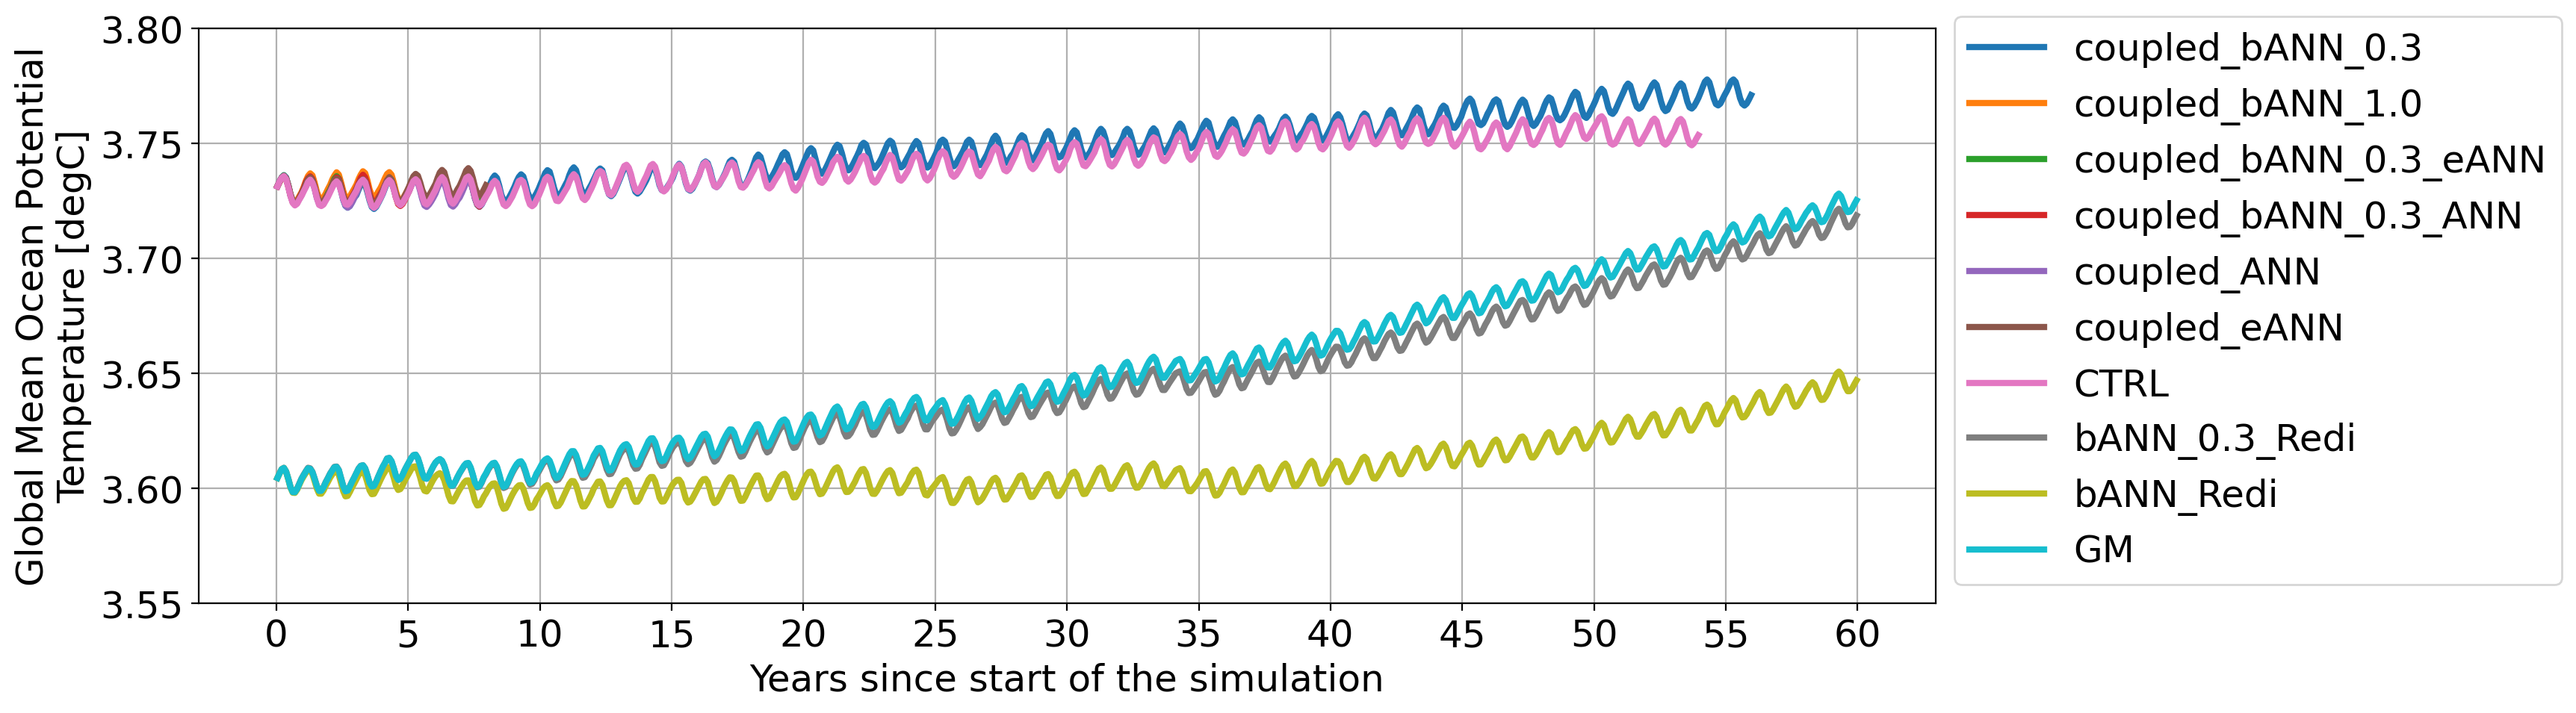

In [10]:
%matplotlib inline

fig, ax = plt.subplots(dpi=200)
for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0', 'coupled_bANN_0.3_eANN', 'coupled_bANN_0.3_ANN', 'coupled_ANN', 'coupled_eANN', 'CTRL', 'bANN_0.3_Redi', 'bANN_Redi', 'GM']:
    dd[exp].thetaoga.plot(ax=ax, label=exp, lw=3)
    ax.set_title('')
    #plt.legend()
plt.xlabel('Years since start of the simulation')

time = dd[exp].thetaoga.time.values

# Build vertical lines every 5 years
years = range(time[0].year, time[-1].year + 2, 5)
ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]

plt.xticks(ticks, np.arange(0,65,5))
plt.grid()

plt.ylim([3.55,3.8])
plt.legend(bbox_to_anchor=(1,0.),loc='lower left')

plt.savefig('PNG_coupled/T_timeseries_legend.png',dpi=200, bbox_inches='tight')

# Ice Volume

In [13]:
from dask.diagnostics import ProgressBar
for exp in ['CTRL', 'coupled_bANN_0.3', 'coupled_bANN_1.0', 'coupled_bANN_0.3_eANN', 'coupled_bANN_0.3_ANN', 'coupled_ANN', 'coupled_eANN']:
    exps[exp].compute_ice()

Reading dataset...
[########################################] | 100% Completed | 108.38 s
Reading dataset...
[########################################] | 100% Completed | 113.97 s
Reading dataset...
[########################################] | 100% Completed | 10.66 ss
Reading dataset...
[########################################] | 100% Completed | 8.36 sms
Reading dataset...
[########################################] | 100% Completed | 9.26 sms
Reading dataset...
[########################################] | 100% Completed | 9.45 sms
Reading dataset...
[########################################] | 100% Completed | 9.05 sms


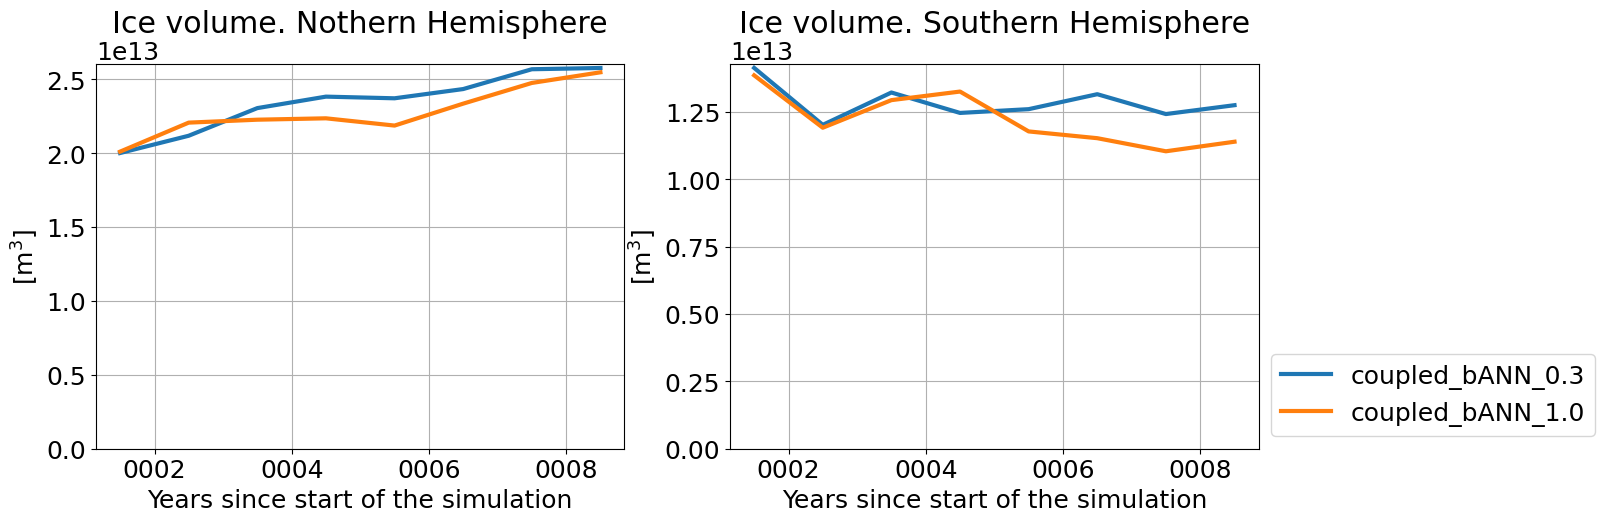

In [24]:
%matplotlib inline


plt.subplot(1,2,1)
for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0']:
    exps[exp].ice_volume().ice_volume_NH.coarsen(time=12).mean()[:8].plot(label=exp, lw=3)
    #plt.legend()
plt.xlabel('Years since start of the simulation')
plt.title('Ice volume. Nothern Hemisphere')

time = dd[exp].thetaoga.time.values

# Build vertical lines every 5 years
# years = range(time[0].year, time[8*12].year, 1)
# ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
plt.ylabel('[m$^3$]')

#plt.xticks(ticks, np.arange(0,10,1))
plt.grid()
plt.ylim([0,None])

plt.subplot(1,2,2)
for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0']:
    exps[exp].ice_volume().ice_volume_SH.coarsen(time=12).mean()[:8].plot(label=exp, lw=3)
plt.legend(bbox_to_anchor=(1,0.),loc='lower left')
plt.xlabel('Years since start of the simulation')
plt.title('Ice volume. Southern Hemisphere')

time = dd[exp].thetaoga.time.values

# Build vertical lines every 5 years
# years = range(time[0].year, time[8*12].year, 1)
# ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
plt.ylabel('[m$^3$]')

#plt.xticks(ticks, np.arange(0,10,1))
plt.grid()
plt.ylim([0,None])

plt.savefig('PNG_coupled/ice_volume.png',dpi=200, bbox_inches='tight')

# Plot heat transport

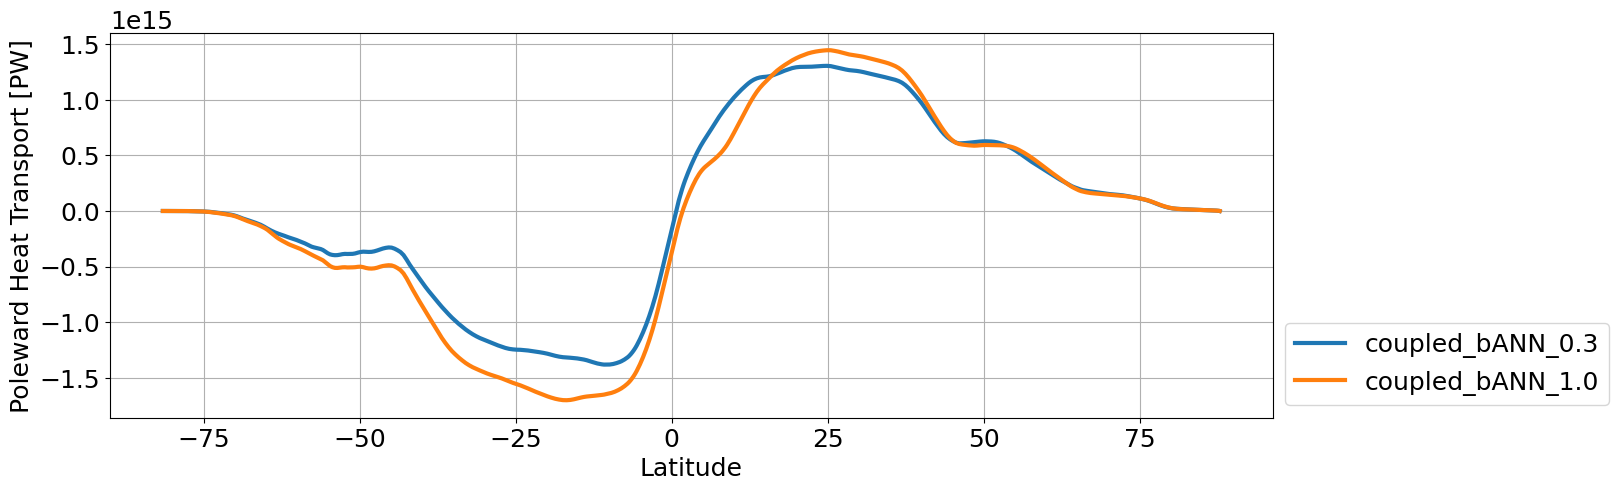

In [20]:
#for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0', 'coupled_bANN_0.3_eANN', 'coupled_bANN_0.3_ANN', 'coupled_ANN', 'coupled_eANN', 'CTRL']:
for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0']:
    experiment = exps[exp]
    advective, neutral_diffusion, horizontal_diffusion = experiment.heat_transport()
    transport = advective + neutral_diffusion + horizontal_diffusion

    transport.sum('xh').plot(label=exp, lw=3)
plt.legend(bbox_to_anchor=(1,0.),loc='lower left')
plt.xlabel('Latitude')
plt.ylabel('Poleward Heat Transport [PW]')
plt.grid()
plt.savefig('PNG_coupled/heat_transport.png')

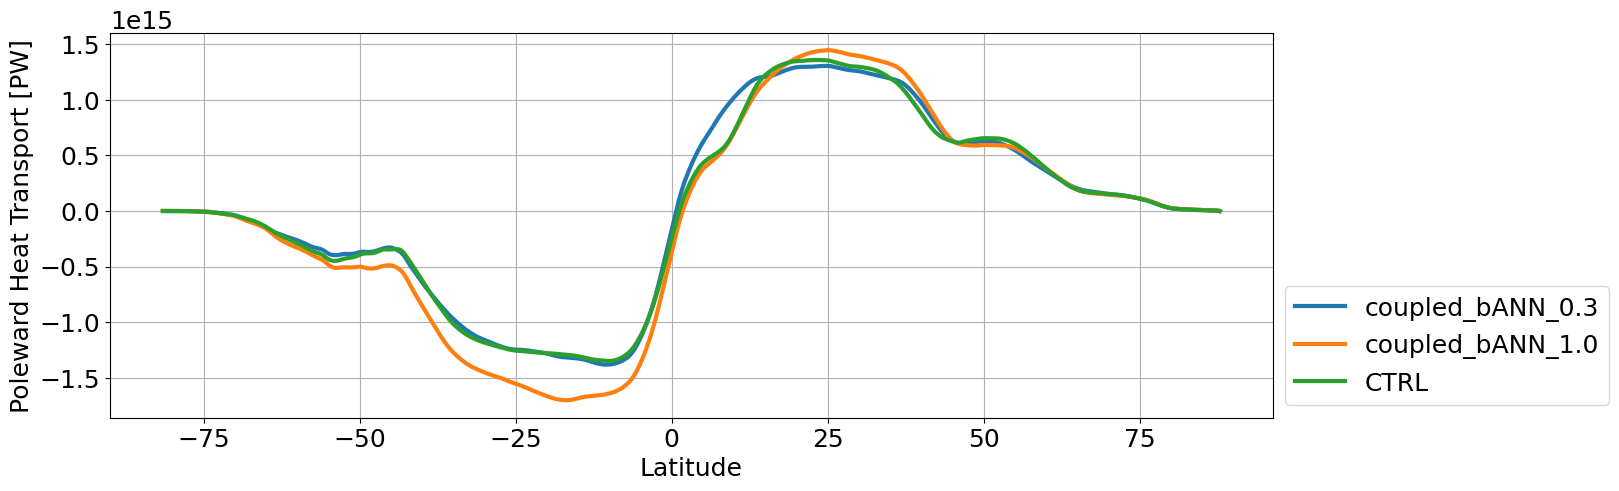

In [ ]:
for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0',  'CTRL']:
    experiment = exps[exp]
    advective, neutral_diffusion, horizontal_diffusion = experiment.heat_transport()
    transport = advective + neutral_diffusion + horizontal_diffusion

    transport.sum('xh').plot(label=exp, lw=3)
plt.legend(bbox_to_anchor=(1,0.),loc='lower left')
plt.xlabel('Latitude')
plt.ylabel('Poleward Heat Transport [PW]')
plt.grid()
plt.savefig('PNG_coupled/heat_transport.png')

In [29]:
basin_code_xr = exps['CTRL'].basin_code_xr
atl = (basin_code_xr.sel(region='MedSea') + basin_code_xr.sel(region='HudsonBay') +     \
      basin_code_xr.sel(region='Arctic') + basin_code_xr.sel(region='AtlanticOcean') + \
      basin_code_xr.sel(region='BlackSea'))
atl['region'] = 'Altantic mask'

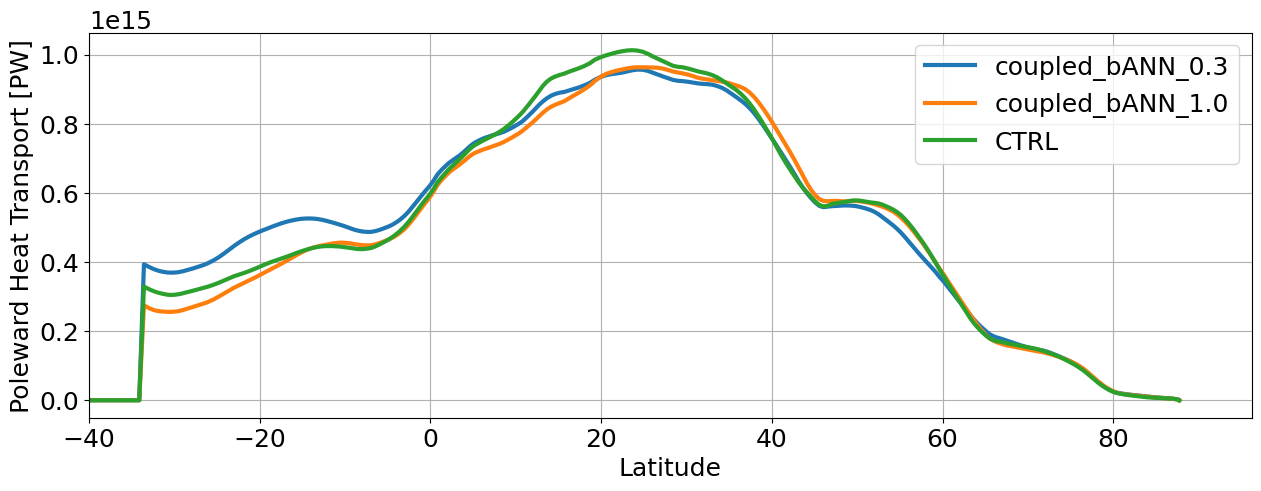

In [30]:
for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0',  'CTRL']:
    experiment = exps[exp]
    advective, neutral_diffusion, horizontal_diffusion = experiment.heat_transport()
    transport = (advective + neutral_diffusion + horizontal_diffusion) * atl.values

    transport.sum('xh').plot(label=exp, lw=3)
plt.legend()
plt.xlabel('Latitude')
plt.ylabel('Poleward Heat Transport [PW]')
plt.xlim([-40,None])
plt.grid()
plt.savefig('PNG_coupled/heat_transport_Atlnatic.png')

# MOC

In [31]:
import intake
catalog = intake.open_catalog('/glade/u/home/gmarques/libs/oce-catalogs/reference-datasets.yml')
rapid = catalog['moc-rapid'].to_dask()

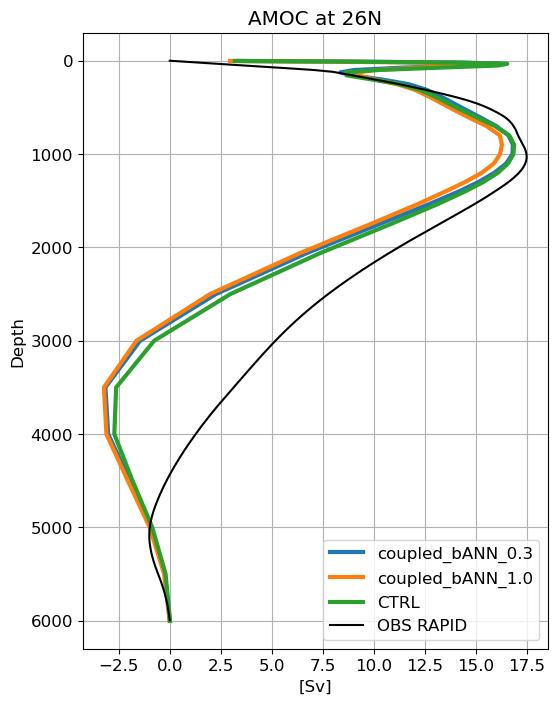

In [32]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(6,8))
for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0',  'CTRL']:
    xr.open_dataset(f'ncfiles_coupled/{exp}_MOC.nc').amoc.sel(yq=26,method='nearest').plot(label=exp, y='zl', lw=3)
rapid.stream_function_mar.mean('time').plot(color='k', label='OBS RAPID', y='depth')
plt.gca().invert_yaxis()
plt.xticks(np.arange(-2.5,20,2.5))
plt.grid()
plt.legend()
plt.title('AMOC at 26N')
plt.ylabel('Depth')
plt.xlabel('[Sv]')

plt.savefig('PNG_coupled/AMOC_RAPID.png', dpi=200)

# Drake Transport

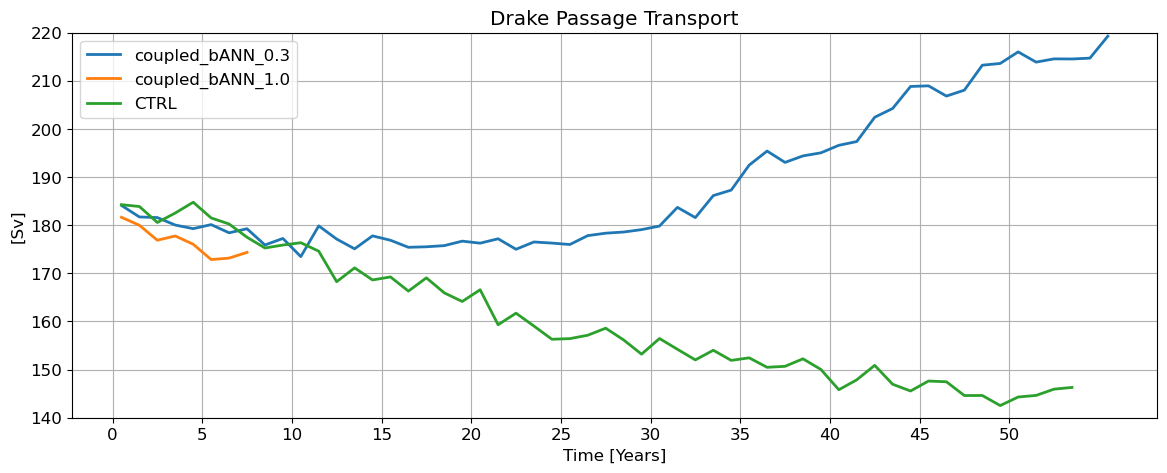

In [36]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(14,5))
for exp in ['coupled_bANN_0.3', 'coupled_bANN_1.0',  'CTRL']:
    xr.open_dataset(f'ncfiles_coupled/{exp}_section_transports.nc').transport.isel(sections=5).coarsen({'time':12}).mean().plot(label=exp, lw=2)
plt.grid()
plt.legend()
plt.title('Drake Passage Transport')
plt.xlabel('Time [Years]')
plt.ylabel('[Sv]')
plt.ylim([140,220])

# Build vertical lines every 5 years
years = range(time[0].year, time[-1].year + 2, 5)
ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
plt.xticks(ticks, np.arange(0,55,5))

plt.savefig('PNG_coupled/Drake.png', dpi=200)

In [16]:
def zonal_ave(array, geolat):
    """Bin 2D array into 1-degree latitude bands using geolat (works on tripolar grids)."""
    # Define edges between grid cells as bin edges, discarding a couple of boundary points
    if geolat is not None:
        bins = array.yh.values
        bins = (bins[0:-1] + bins[1:]) / 2
        return array.groupby_bins(geolat, bins=bins).mean()
    else:
        return array.mean('xh')

# Temperature response

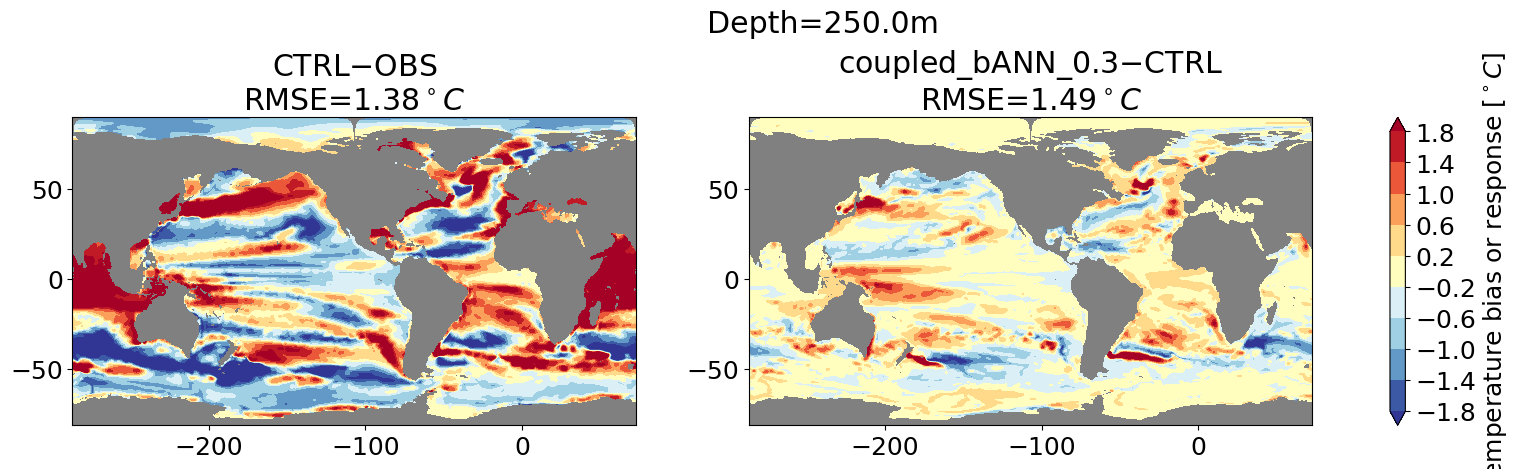

In [13]:
from mom6_tools.m6plot import myStats
%matplotlib inline
plt.figure(figsize=(20,4))
area = np.ma.masked_invalid(exps['CTRL'].area) # All computations including area will be masked array from now on
zl = 10
exp='coupled_bANN_0.3'
bias = exps['CTRL'].thetao().thetao_bias[zl]
response = (exps[exp].thetao().thetao - exps['CTRL'].thetao().thetao)[zl]
geolon = exps['CTRL'].grd.geolon
geolat = exps['CTRL'].grd.geolat
cmap = plt.cm.RdYlBu_r.copy()
vmin,vmax,ci = -1.8,1.8,0.4
cilev = np.arange(vmin,vmax+ci,ci)
plt.subplot(1,2,1)
plt.contourf(geolon, geolat, bias, cmap=cmap, levels=cilev, extend='both')
_, _, _, _, error = myStats(np.ma.masked_invalid(bias), area)
plt.title(f'CTRL$-$OBS\nRMSE={error:.2f}$^\circ C$')
plt.gca().set_facecolor('gray')
plt.subplot(1,2,2)
im = plt.contourf(geolon, geolat, response, cmap=cmap, levels=cilev, extend='both')
_, _, _, _, error = myStats(np.ma.masked_invalid(exps[exp].thetao().thetao_bias[zl]), area)
plt.title(f'{exp}$-$CTRL\nRMSE={error:.2f}$^\circ C$')
plt.gca().set_facecolor('gray')
plt.colorbar(im,ax=plt.gcf().axes, label='Temperature bias or response [$^\circ C]$', extend='both')
depth = round(float(bias.z_l), 1)
plt.suptitle(f'Depth={depth}m', y=1.15)
plt.savefig(f'PNG_coupled/response_{zl}z_{exp}.png',dpi=200, bbox_inches='tight')

# Zonal average

In [14]:
import intake
catalog = intake.open_catalog('/glade/u/home/gmarques/libs/oce-catalogs/reference-datasets.yml')
thetao_obs = catalog['woa-2018-tx2_3v2-annual-all'].to_dask().thetao.values + 0*exps['CTRL'].thetao().thetao

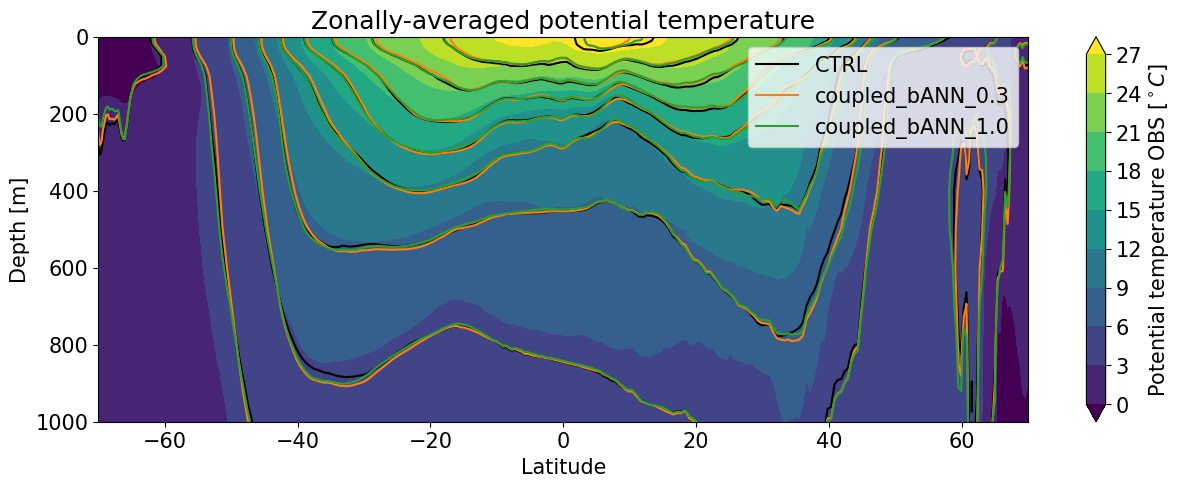

In [17]:
plt.rcParams.update({'font.size': 15})
geolat = exps['CTRL'].grd.geolat
levels=np.arange(0,30,3)
cs = zonal_ave(thetao_obs, geolat).plot.contourf(levels=levels, cmap='viridis', extend='both',
                                                 cbar_kwargs={'label': 'Potential temperature OBS [$^\circ C$]'})
zonal_ave(exps['CTRL'].thetao().thetao, geolat).plot.contour(levels=levels, colors='k')
zonal_ave(exps['coupled_bANN_0.3'].thetao().thetao, geolat).plot.contour(levels=levels, colors='tab:orange')
zonal_ave(exps['coupled_bANN_1.0'].thetao().thetao, geolat).plot.contour(levels=levels, colors='tab:green')
plt.ylim([0,1000])
plt.xlim([-70,70])
plt.gca().invert_yaxis()
plt.xlabel('Latitude')
plt.title('Zonally-averaged potential temperature')
plt.ylabel('Depth [m]')
plt.plot([None], [None], color='k', label='CTRL')
plt.plot([None], [None], color='tab:orange', label='coupled_bANN_0.3')
plt.plot([None], [None], color='tab:green', label='coupled_bANN_1.0')
plt.legend()
plt.savefig(f'PNG_coupled/thetao_zonal_ave.png',dpi=200, bbox_inches='tight')


# Zonally-averaged density

In [18]:
import gsw
woa_obs = catalog['woa-2018-tx2_3v2-annual-all'].to_dask()
geolon = exps['CTRL'].grd.geolon

In [19]:
# Simplified expression for Potential density anomaly ref 2000 dbar
sigma2_obs = gsw.sigma2(woa_obs.so, woa_obs.thetao) + geolon*0

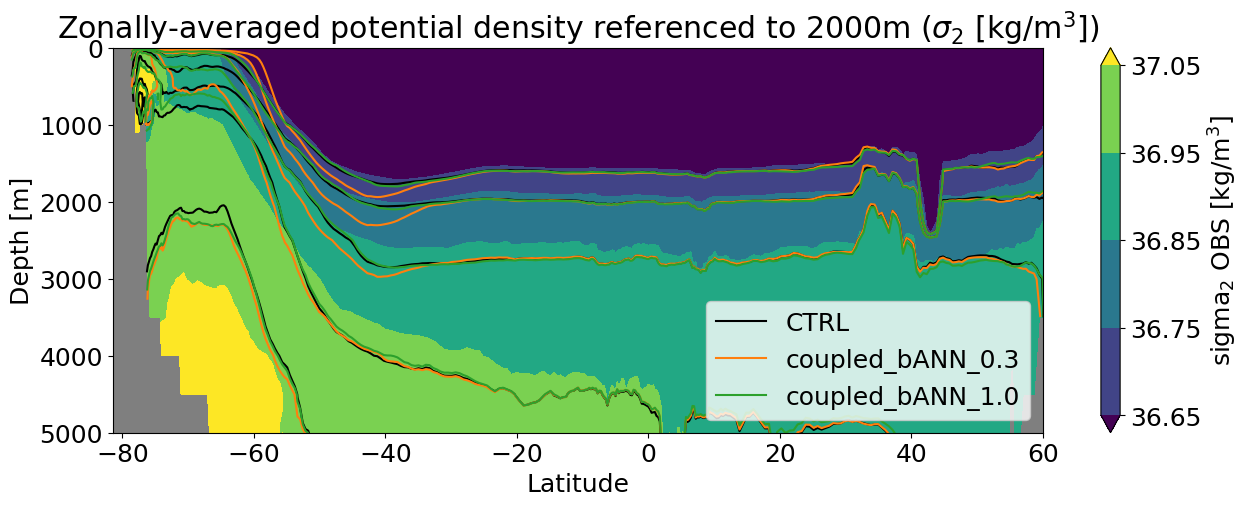

In [29]:
plt.rcParams.update({'font.size': 18})
levels = np.array([36.65,36.75,36.85,36.95, 37.05])
zonal_ave(sigma2_obs, geolat).plot.contourf(levels=levels, cmap='viridis', cbar_kwargs={'label': 'sigma$_2$ OBS [kg/m$^3$]'})
zonal_ave(exps['CTRL'].sigma2(), geolat).plot.contour(levels=levels, colors='k')
zonal_ave(exps['coupled_bANN_0.3'].sigma2(), geolat).plot.contour(levels=levels, colors='tab:orange')
zonal_ave(exps['coupled_bANN_1.0'].sigma2(), geolat).plot.contour(levels=levels, colors='tab:green')
plt.ylim([0,5000])
plt.xlim([None,60])
plt.gca().invert_yaxis()
plt.xlabel('Latitude')
plt.title('Zonally-averaged potential density referenced to 2000m ($\sigma_2$ [kg/m$^3$])')
plt.ylabel('Depth [m]')
plt.plot([None], [None], color='k', label='CTRL')
plt.plot([None], [None], color='tab:orange', label='coupled_bANN_0.3')
plt.plot([None], [None], color='tab:green', label='coupled_bANN_1.0')
plt.legend(loc='lower right')
plt.gca().set_facecolor('tab:gray')
plt.savefig(f'PNG_coupled/sigma2_zonal_ave.png',dpi=200, bbox_inches='tight')


# MLD bias-response

In [28]:
# See https://webext.cgd.ucar.edu/GIAF/g.e30_a08g.GW_JRA.TL319_t232_wgx3_hycom1_N75.2026.006/ocn/mld.html for example
import intake
grd = exps['CTRL'].grd
obs = 'mld-deboyer-2023-tx2_3v2'
catalog = intake.open_catalog('/glade/u/home/gmarques/libs/oce-catalogs/reference-datasets.yml')
mld_obs = catalog[obs].to_dask()
mld_obs = mld_obs.rename({'time' : 'month'})
mld_obs["month"] = np.arange(1,len(mld_obs.month)+1)
months = [0,1,2]
obs_JFM = np.ma.masked_invalid(mld_obs.mld.isel(month=months).mean('month').values)
months = [6,7,8]
obs_JAS = np.ma.masked_invalid(mld_obs.mld.isel(month=months).mean('month').values)
obs_winter = obs_JAS.copy(); obs_summer = obs_JAS.copy()
j = int(np.abs( grd.geolat[:,0] - 0. ).argmin())
obs_winter[j::,:] = obs_JFM[j::,:]
obs_summer[0:j,:] = obs_JFM[0:j,:]

obs_winter = obs_winter.data + grd.geolon*0
obs_summer = obs_summer.data + grd.geolon*0

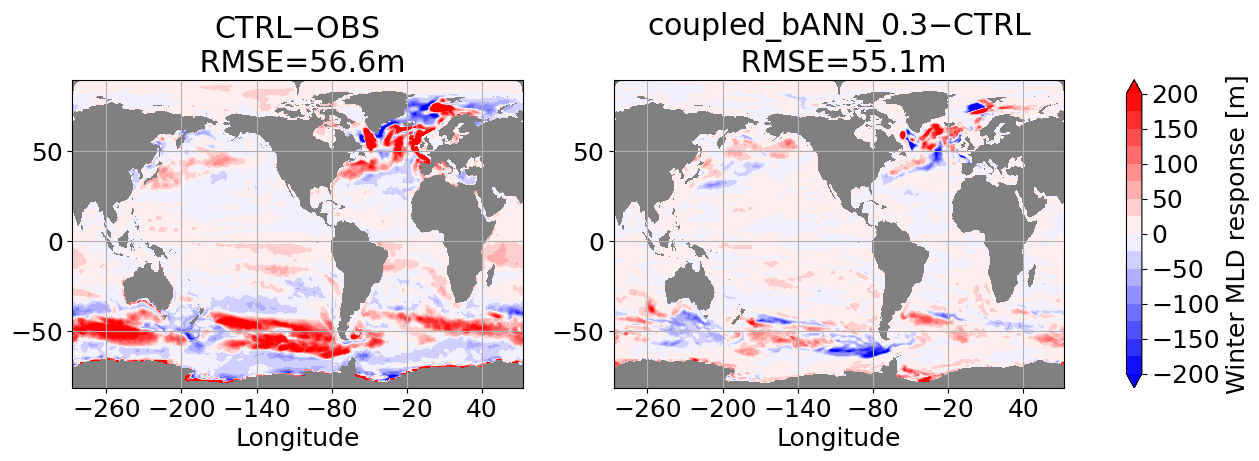

In [36]:
from mom6_tools.m6plot import myStats

exp = 'coupled_bANN_0.3'

%matplotlib inline
plt.figure(figsize=(16,4))
vmax=200
geolon = exps['CTRL'].grd.geolon
geolat = exps['CTRL'].grd.geolat
area = np.ma.masked_invalid(exps['CTRL'].area) # All computations including area will be masked array from now on
control_winter = exps['CTRL'].mld_winter().MLD_winter
bias = control_winter - obs_winter

plt.subplot(1,2,1)
im = plt.contourf(geolon, geolat, bias, extend='both', levels=np.linspace(-vmax, vmax, 17), cmap='bwr')
_, _, _, _, error = myStats(control_winter - obs_winter, area)
plt.title(f'CTRL$-$OBS \n RMSE={error:.1f}m')
plt.gca().set_facecolor('gray')
plt.xticks(np.arange(-260,60,60))
plt.xlabel('Longitude')
plt.grid()

plt.subplot(1,2,2)
model_winter = exps[exp].mld_winter().MLD_winter
response = model_winter - control_winter
_, _, _, _, error = myStats(model_winter - obs_winter, area)
im = plt.contourf(geolon, geolat, response, extend='both', levels=np.linspace(-vmax, vmax, 17), cmap='bwr')
plt.title(f'{exp}$-$CTRL \n RMSE={error:.1f}m')
plt.gca().set_facecolor('gray')
plt.xticks(np.arange(-260,60,60))
plt.xlabel('Longitude')
plt.grid()


plt.colorbar(im,ax=plt.gcf().axes, label='Winter MLD response [m]', extend='both')
plt.savefig('PNG_coupled/MLD_winter_response.png',dpi=200, bbox_inches='tight')

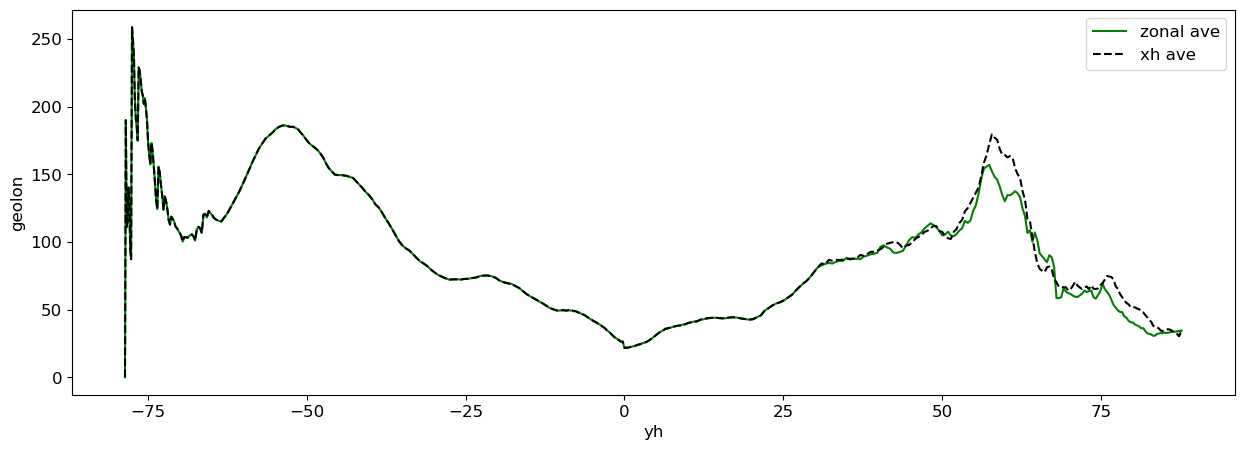

In [60]:
%matplotlib inline
zonal_ave(obs_winter, grd.geolat).plot(label='zonal ave', color='g')
zonal_ave(obs_winter, None).plot(color='k', label='xh ave', ls='--')
plt.legend()
plt.show()

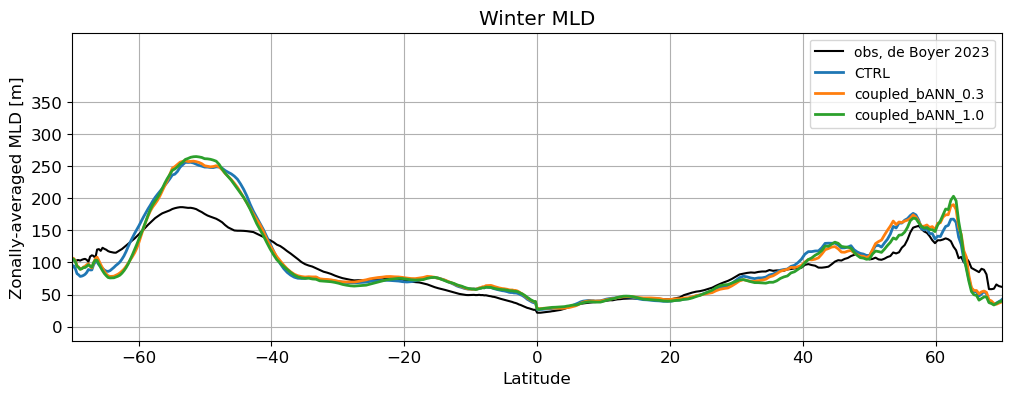

In [37]:
plt.figure(figsize=(12,4))
plt.rcParams.update({'font.size': 12})
geolat = grd.geolat
zonal_ave(obs_winter, geolat).plot(label='obs, de Boyer 2023', color='k')
model_winter = exps['CTRL'].mld_winter().MLD_winter
zonal_ave(model_winter, geolat).plot(label='CTRL', lw=2)
model_winter = exps['coupled_bANN_0.3'].mld_winter().MLD_winter
zonal_ave(model_winter, geolat).plot(label='coupled_bANN_0.3', lw=2)

model_winter = exps['coupled_bANN_1.0'].mld_winter().MLD_winter
zonal_ave(model_winter, geolat).plot(label='coupled_bANN_1.0', lw=2)


plt.xlim(-70,70)
plt.legend(fontsize=10)
plt.grid()
plt.yticks(np.arange(0,400,50));
plt.xlabel('Latitude')
plt.title('Winter MLD')
plt.ylabel('Zonally-averaged MLD [m]')
plt.savefig('PNG_coupled/winter_MLD_zonal.png', dpi=200)

### MLD RMSE Zonal plot

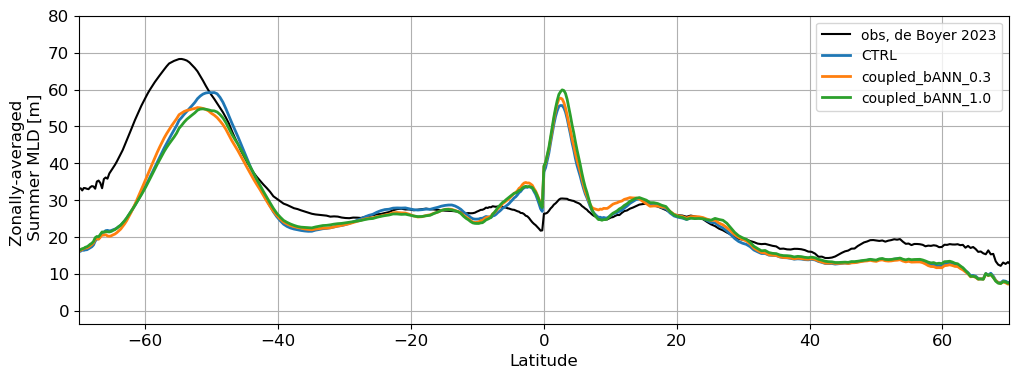

In [51]:
plt.figure(figsize=(12,4))
plt.rcParams.update({'font.size': 12})
zonal_ave(obs_summer, geolat).plot(label='obs, de Boyer 2023', color='k')
model_summer = exps['CTRL'].mld_summer().MLD_summer
zonal_ave(model_summer, geolat).plot(label='CTRL', lw=2)
model_summer = exps['coupled_bANN_0.3'].mld_summer().MLD_summer
zonal_ave(model_summer, geolat).plot(label='coupled_bANN_0.3', lw=2)
model_summer = exps['coupled_bANN_1.0'].mld_summer().MLD_summer
zonal_ave(model_summer, geolat).plot(label='coupled_bANN_1.0', lw=2)

plt.xlim(-70,70)
plt.legend(fontsize=10)
plt.grid()
plt.yticks(np.arange(0,90,10));
plt.xlabel('Latitude')
plt.ylabel('Zonally-averaged \n Summer MLD [m]')
plt.savefig('PNG_coupled/summer_MLD_zonal.png', dpi=200)

# GM overturning

In [52]:
CTRL = xr.open_dataset('ncfiles_coupled/CTRL_MOC_sigma2.nc')
bANN_0p3 = xr.open_dataset('ncfiles_coupled/coupled_bANN_0.3_MOC_sigma2.nc')
bANN_1p0 = xr.open_dataset('ncfiles_coupled/coupled_bANN_1.0_MOC_sigma2.nc')

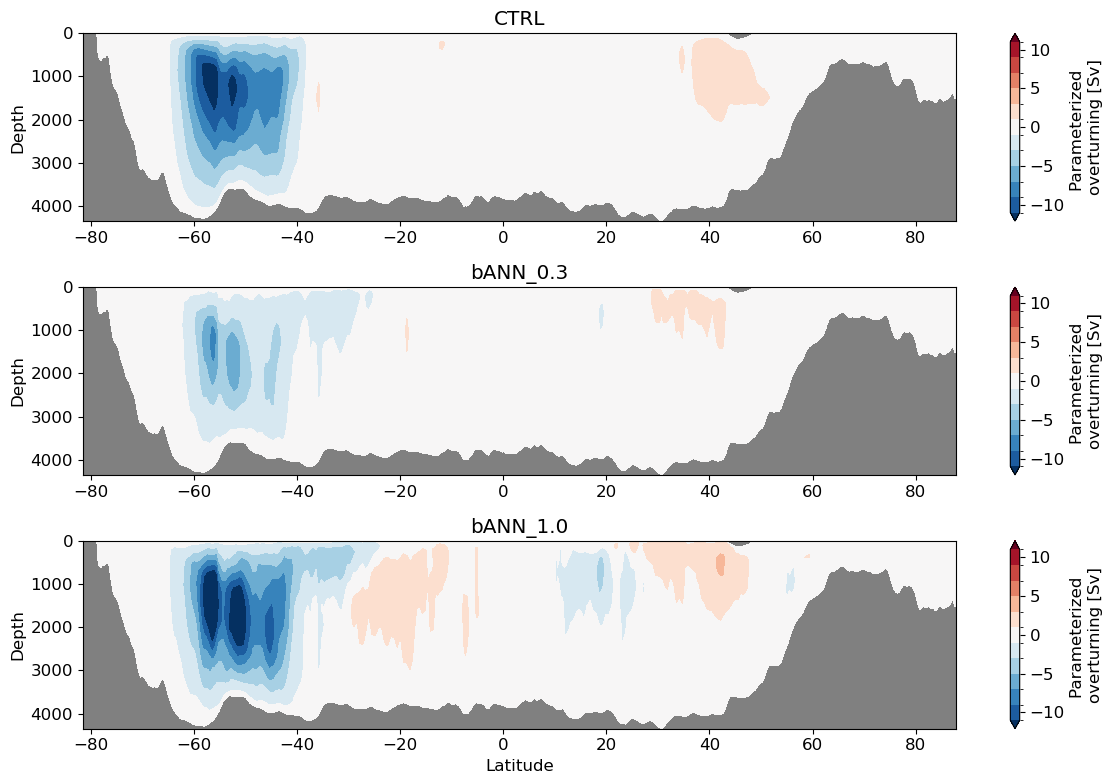

In [53]:
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
CTRL.moc_GM.plot.contourf(x='yq', y='depth', levels=[-11,-9,-7,-5,-3,-1,1,3,5,7,9,11], cmap='RdBu_r', extend='both',
cbar_kwargs={'label': 'Parameterized \noverturning [Sv]', 'ticks': np.array([-10,-5,0,5,10])})
plt.gca().invert_yaxis()
plt.title('CTRL')
plt.ylabel('Depth')
plt.xlabel('')
plt.gca().set_facecolor('gray')

plt.subplot(3,1,2)
bANN_0p3.moc_GM.plot.contourf(x='yq', y='depth', levels=[-11,-9,-7,-5,-3,-1,1,3,5,7,9,11], cmap='RdBu_r', extend='both',
cbar_kwargs={'label': 'Parameterized \noverturning [Sv]', 'ticks': np.array([-10,-5,0,5,10])})
plt.gca().invert_yaxis()
plt.title('bANN_0.3')
plt.ylabel('Depth')
plt.xlabel('')
plt.gca().set_facecolor('gray')

plt.subplot(3,1,3)
bANN_1p0.moc_GM.plot.contourf(x='yq', y='depth', levels=[-11,-9,-7,-5,-3,-1,1,3,5,7,9,11], cmap='RdBu_r', extend='both',
cbar_kwargs={'label': 'Parameterized \noverturning [Sv]', 'ticks': np.array([-10,-5,0,5,10])})
plt.gca().invert_yaxis()
plt.title('bANN_1.0')
plt.ylabel('Depth')
plt.xlabel('Latitude')
plt.gca().set_facecolor('gray')

plt.tight_layout()

plt.savefig('PNG_coupled/parameterized_overturning.png', dpi=200)